# BTC exploratory pipeline validation v1

## tl;dr

exploratory期間だけで連続5分event tableと物理分離したoutcome tableを生成できた。取引ゼロと欠測は分離され、event側にfuture return / MFE / MAEは存在しない。ただしhistorical asset contextが0%のためcore feature-ready rowは0であり、仮説の成績評価には進まない。

## Context & Methods

### Key assumptions

- 対象は再構成品質を通過した44 walletの固定取得期間。
- validation / held-outの処理件数は0。閾値選択にも使わない。
- 5分足だけを使うためtime-to-high/lowは5分解像度。
- OI、asset context、market trades、wallet state、liquidation eventは推定しない。

H02はNEW entryだけ、H04はpre-add状態が復元できるADDだけ、H05はwalletの過去20 position-increase notionalだけからpast-only baselineを作る。H07は別fileで必要な将来5分足がすべて揃う場合だけ計算する。

## Data

In [1]:
import csv
import json
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "analysis/btc-exploratory-pipeline-v1/pipeline_summary.json").exists()
)
ARTIFACT = ROOT / "analysis/btc-exploratory-pipeline-v1"
summary = json.loads((ARTIFACT / "pipeline_summary.json").read_text(encoding="utf-8"))
with (ARTIFACT / "events_exploratory.csv").open(encoding="utf-8", newline="") as handle:
    events = list(csv.DictReader(handle))
with (ARTIFACT / "outcomes_exploratory.csv").open(encoding="utf-8", newline="") as handle:
    outcomes = list(csv.DictReader(handle))

{
    "event_rows": len(events),
    "outcome_rows": len(outcomes),
    "split": summary["split"],
    "validation_or_held_out_rows_processed": summary["validation_or_held_out_rows_processed"],
}

{'event_rows': 5318,
 'outcome_rows': 21272,
 'split': 'exploratory',
 'validation_or_held_out_rows_processed': 0}

## Results

In [2]:
event_fields = set(events[0])
outcome_fields = set(outcomes[0])
{
    "event_keys_unique": len({(r["sample_version"], r["cutoff_ms"]) for r in events}) == len(events),
    "outcome_keys_unique": len({(r["sample_version"], r["cutoff_ms"], r["horizon_min"]) for r in outcomes}) == len(outcomes),
    "future_fields_absent_from_event": not ({"future_return", "mfe_up", "mae_down"} & event_fields),
    "future_fields_present_in_outcome": {"future_return", "mfe_up", "mae_down"} <= outcome_fields,
}

{'event_keys_unique': True,
 'outcome_keys_unique': True,
 'future_fields_absent_from_event': True,
 'future_fields_present_in_outcome': True}

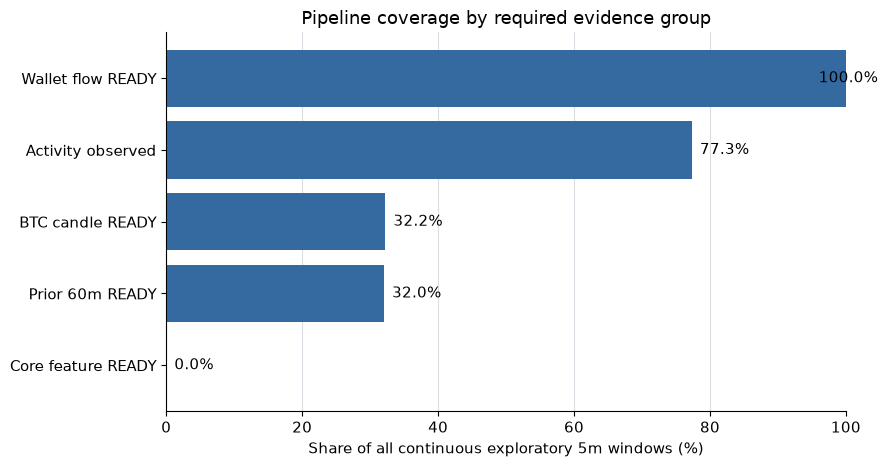

In [3]:
coverage = {
    "Wallet flow READY": summary["wallet_flow_ready_rows"],
    "Activity observed": summary["activity_event_rows"],
    "BTC candle READY": summary["btc_candle_ready_rows"],
    "Prior 60m READY": summary["prior_60m_ready_rows"],
    "Core feature READY": summary["core_feature_ready_rows"],
}
total = summary["event_rows"]
labels = list(coverage)
values = [100 * coverage[label] / total for label in labels]

plt.rcParams.update({"font.size": 11, "axes.titlesize": 13, "axes.labelsize": 11})
fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.barh(labels[::-1], values[::-1], color="#356AA0")
ax.set_xlim(0, 100)
ax.set_xlabel("Share of all continuous exploratory 5m windows (%)")
ax.set_title("Pipeline coverage by required evidence group")
ax.grid(axis="x", color="#D9DEE5", linewidth=0.8)
ax.set_axisbelow(True)
for bar, value in zip(bars, values[::-1]):
    ax.text(min(value + 1.2, 96), bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", va="center")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
fig.savefig(ARTIFACT / "pipeline_coverage.png", dpi=160, bbox_inches="tight")
display(fig, metadata={"image/png": {"alt": "Horizontal bar chart of exploratory five-minute window coverage: wallet flow 100%, activity 77.3%, BTC candle 32.2%, prior 60 minutes 32.0%, and core feature ready 0%."}})
plt.close(fig)

保存済みBTC candleはexploratory期間の一部だけを覆う。historical asset contextがないため、wallet flowとcandleが揃ってもcore `feature_ready`は0のままにする。

In [4]:
{
    "zero_activity_rows": summary["zero_activity_event_rows"],
    "activity_rows": summary["activity_event_rows"],
    "new_entry_feature_rows": summary["new_entry_rows"],
    "averaging_down_feature_rows": summary["averaging_down_rows"],
    "size_baseline_ready_rows": summary["size_baseline_ready_rows"],
    "price_outcome_ready_by_horizon": summary["price_outcome_ready_by_horizon"],
}

{'zero_activity_rows': 1206,
 'activity_rows': 4112,
 'new_entry_feature_rows': 662,
 'averaging_down_feature_rows': 251,
 'size_baseline_ready_rows': 2593,
 'price_outcome_ready_by_horizon': {'5': 1714,
  '15': 1714,
  '30': 1714,
  '60': 1714}}

## Takeaways

1. 連続5分windowを保持し、取引ゼロと欠測を区別できる。
2. H02/H04/H05のoutcome-free fieldは生成できるが、発火件数は仮説成績ではない。
3. H07 outcomeは別fileへ一意keyで保存され、欠測時はNULLのまま。
4. OI等のcore seriesがないため、現データでconfirmatory backtestや閾値採否へ進まない。
5. 次の判断は、partial pipelineを許容してH02/H04/H05の探索を始めるか、forward収集でcore coverageを作るかを品質契約に沿って決めること。